Title : shortest path 
Melika Jalali


Part A1 :
catch two point by clicking on map as input .

In [1]:
import osmnx as ox
import networkx as nx
import ipyleaflet
from IPython.display import display
m = ipyleaflet.Map(center=(35.6892, 51.3890), zoom=12)
G = ox.graph_from_place("Tehran, Iran", network_type="drive")
clicked_locations = []
def on_map_click(**click):
    global clicked_locations
    if click.get("type") == "click": 
        location = click.get("coordinates")
        if location:
            clicked_locations.append(location)
            print(f"Saved location: {location}")  
            marker = ipyleaflet.Marker(location=location, draggable=False)
            m.add_layer(marker)
m.on_interaction(on_map_click)
display(m)

Map(center=[35.6892, 51.389], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoo…

Part A2 :
Calculate shortest path and show it in visualation map as output.

In [2]:
start_location = (clicked_locations[0][0],clicked_locations[0][1]) 
end_location = (clicked_locations[1][0],clicked_locations[1][1])    
orig = ox.distance.nearest_nodes(G, start_location[1], start_location[0])
dest = ox.distance.nearest_nodes(G, end_location[1], end_location[0])
route = nx.shortest_path(G, source=orig, target=dest, weight="length")
route_coords = [(G.nodes[node]["y"], G.nodes[node]["x"]) for node in route]
m.add_layer(ipyleaflet.Marker(location=start_location, draggable=False, title="Start"))
m.add_layer(ipyleaflet.Marker(location=end_location, draggable=False, title="End"))
line = ipyleaflet.Polyline(locations=route_coords, color="red", weight=5)
m.add_layer(line)
display(m)

Map(bottom=206624.0, center=[35.69745580725804, 51.40296936035157], controls=(ZoomControl(options=['position',…

Part B :
Export the visualation map according to the distances to uinversities

C:\Users\Asus\AppData\Local\Temp\ipykernel_16088\4250957578.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  universities["lon"] = universities.geometry.centroid.x
C:\Users\Asus\AppData\Local\Temp\ipykernel_16088\4250957578.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  universities["lat"] = universities.geometry.centroid.y
C:\Users\Asus\AppData\Local\Temp\ipykernel_16088\4250957578.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings["distance_km"] = buildings.geometry.centroid.apply(lambda x: min(x.distance(pt) for pt in reference_points))
C:\Users\As

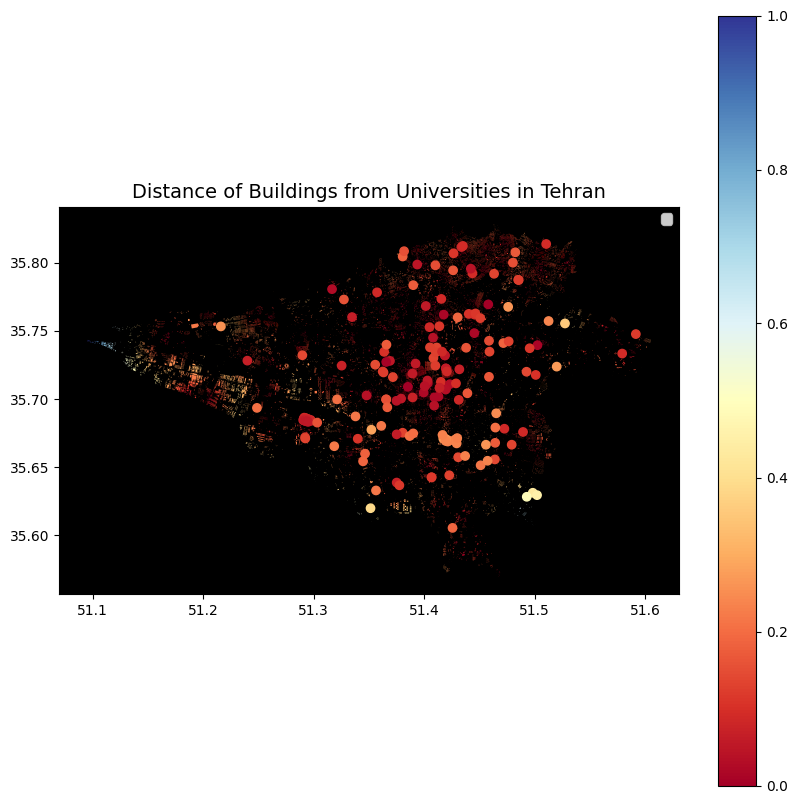

In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import osmnx as ox
universities = ox.features_from_place("Tehran, Iran", tags={'amenity': 'university'})
buildings = ox.features_from_place("Tehran, Iran", tags={"building": True})
universities["lon"] = universities.geometry.centroid.x
universities["lat"] = universities.geometry.centroid.y
reference_points = [Point(lon, lat) for lon, lat in zip(universities["lon"], universities["lat"])]
ref_gdf = gpd.GeoDataFrame(geometry=reference_points)
buildings["distance_km"] = buildings.geometry.centroid.apply(lambda x: min(x.distance(pt) for pt in reference_points))
buildings["normalized_distance"] = (buildings["distance_km"] - buildings["distance_km"].min()) / (buildings["distance_km"].max() - buildings["distance_km"].min())
fig, ax = plt.subplots(figsize=(10, 10))
buildings.plot(ax=ax, column="normalized_distance", cmap="RdYlBu"
,legend=True)
ax.set_facecolor("black")
ax.legend()
ax.set_title("Distance of Buildings from Universities in Tehran", fontsize=14)
plt.show()